# The North Face — Analyse du catalogue produits

The North Face souhaite améliorer son expérience e-commerce avec deux axes :
- Un **système de recommandation** pour suggérer des produits similaires
- Une **extraction de thèmes** pour mieux structurer le catalogue

**Plan :**
1. Chargement et nettoyage des données
2. Preprocessing NLP (lemmatisation, stopwords)
3. Vectorisation TF-IDF
4. Partie 1 — Clustering DBSCAN
5. Partie 2 — Système de recommandation
6. Partie 3 — Topic modeling (LSA / TruncatedSVD)

## 1. Setup

In [2]:
# Télécharger le modèle spaCy si pas encore installé
import subprocess
subprocess.run(['python', '-m', 'spacy', 'download', 'en_core_web_sm'], check=False)

  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl (12.8 MB)
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


CompletedProcess(args=['python', '-m', 'spacy', 'download', 'en_core_web_sm'], returncode=0)

In [3]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud

import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import DBSCAN
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

import warnings
warnings.filterwarnings('ignore')

# Charger le modèle spacy anglais
nlp = spacy.load('en_core_web_sm')
print('Setup OK')

Setup OK


## 2. Chargement et nettoyage des données

Le dataset contient 500 descriptions de produits The North Face. Les descriptions incluent du HTML qu'il faut nettoyer avant tout traitement.

In [4]:
df = pd.read_csv('../data/raw/sample-data.csv')
print(f'Shape : {df.shape}')
df.head(3)

Shape : (500, 2)


,id,description
0,1,Active classic boxers - There's a reason why o...
1,2,Active sport boxer briefs - Skinning up Glory ...
2,3,Active sport briefs - These superbreathable no...


In [5]:
def clean_html(text):
    """Supprime les balises HTML et caractères spéciaux."""
    text = re.sub(r'<[^>]+>', ' ', text)       # balises HTML
    text = re.sub(r'&[a-z]+;', ' ', text)      # entités HTML
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)  # caractères non-alphabétiques
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['description_clean'] = df['description'].apply(clean_html)
print('Exemple après nettoyage :')
print(df['description_clean'].iloc[0][:300])

Exemple après nettoyage :
Active classic boxers There s a reason why our boxers are a cult favorite they keep their cool especially in sticky situations The quick drying lightweight underwear takes up minimal space in a travel pack An exposed brushed waistband offers next to skin softness five panel construction with a tradi


## 3. Preprocessing NLP

On utilise **spaCy** pour :
- Passer en minuscules
- Supprimer les stop words
- Lemmatiser chaque mot (garder la forme de base)

In [6]:
def preprocess(text):
    doc = nlp(text.lower())
    tokens = [
        token.lemma_ for token in doc
        if not token.is_stop and not token.is_punct and len(token.lemma_) > 2
    ]
    return ' '.join(tokens)

df['description_processed'] = df['description_clean'].apply(preprocess)
print('Exemple après preprocessing :')
print(df['description_processed'].iloc[0][:300])

Exemple après preprocessing :
active classic boxer reason boxer cult favorite cool especially sticky situation quick dry lightweight underwear take minimal space travel pack expose brush waistband offer skin softness panel construction traditional boxer classic fit functional fly recycle polyester moisture wicke performance inse


## 4. Vectorisation TF-IDF

On transforme les textes en vecteurs numériques avec TF-IDF. On garde les 500 mots les plus significatifs.

In [7]:
vectorizer = TfidfVectorizer(max_features=500)
tfidf_matrix = vectorizer.fit_transform(df['description_processed'])

print(f'Matrice TF-IDF : {tfidf_matrix.shape}')
print('(lignes = produits, colonnes = mots du vocabulaire)')

Matrice TF-IDF : (500, 500)
(lignes = produits, colonnes = mots du vocabulaire)


## Partie 1 — Clustering DBSCAN

On utilise DBSCAN avec la distance **cosine** (adaptée aux textes) pour regrouper les produits dont les descriptions sont proches.

Le paramètre `eps` contrôle la taille des voisinages. Les produits non assignés à un cluster (outliers) sont étiquetés `-1`.

In [8]:
db = DBSCAN(eps=0.65, min_samples=3, metric='cosine')
df['cluster'] = db.fit_predict(tfidf_matrix)

n_clusters = len(set(df['cluster'])) - (1 if -1 in df['cluster'].values else 0)
n_noise    = (df['cluster'] == -1).sum()

print(f'Clusters trouvés : {n_clusters}')
print(f'Outliers         : {n_noise} ({n_noise / len(df) * 100:.1f}%)')
print()
print(df['cluster'].value_counts().sort_index())

Clusters trouvés : 4
Outliers         : 2 (0.4%)

cluster
-1      2
 0    461
 1      8
 2     24
 3      5
Name: count, dtype: int64


### Évaluation de la qualité du clustering

In [ ]:
from sklearn.metrics import silhouette_score

# On évalue uniquement sur les points assignés à un cluster (pas les outliers)
mask_valid = df['cluster'] != -1
X_eval = tfidf_matrix[mask_valid].toarray()
labels_eval = df.loc[mask_valid, 'cluster'].values

if len(set(labels_eval)) > 1:
    sil = silhouette_score(X_eval, labels_eval, metric='cosine')
    print(f"Silhouette Score (cosine) : {sil:.3f}")
    print("(Score entre -1 et 1 — plus c'est proche de 1, plus les clusters sont bien séparés)")
else:
    print("Pas assez de clusters pour calculer le silhouette score.")

### Wordclouds par cluster

Pour chaque cluster, on affiche un wordcloud des mots les plus fréquents dans les descriptions. Ça permet de comprendre le thème de chaque groupe.

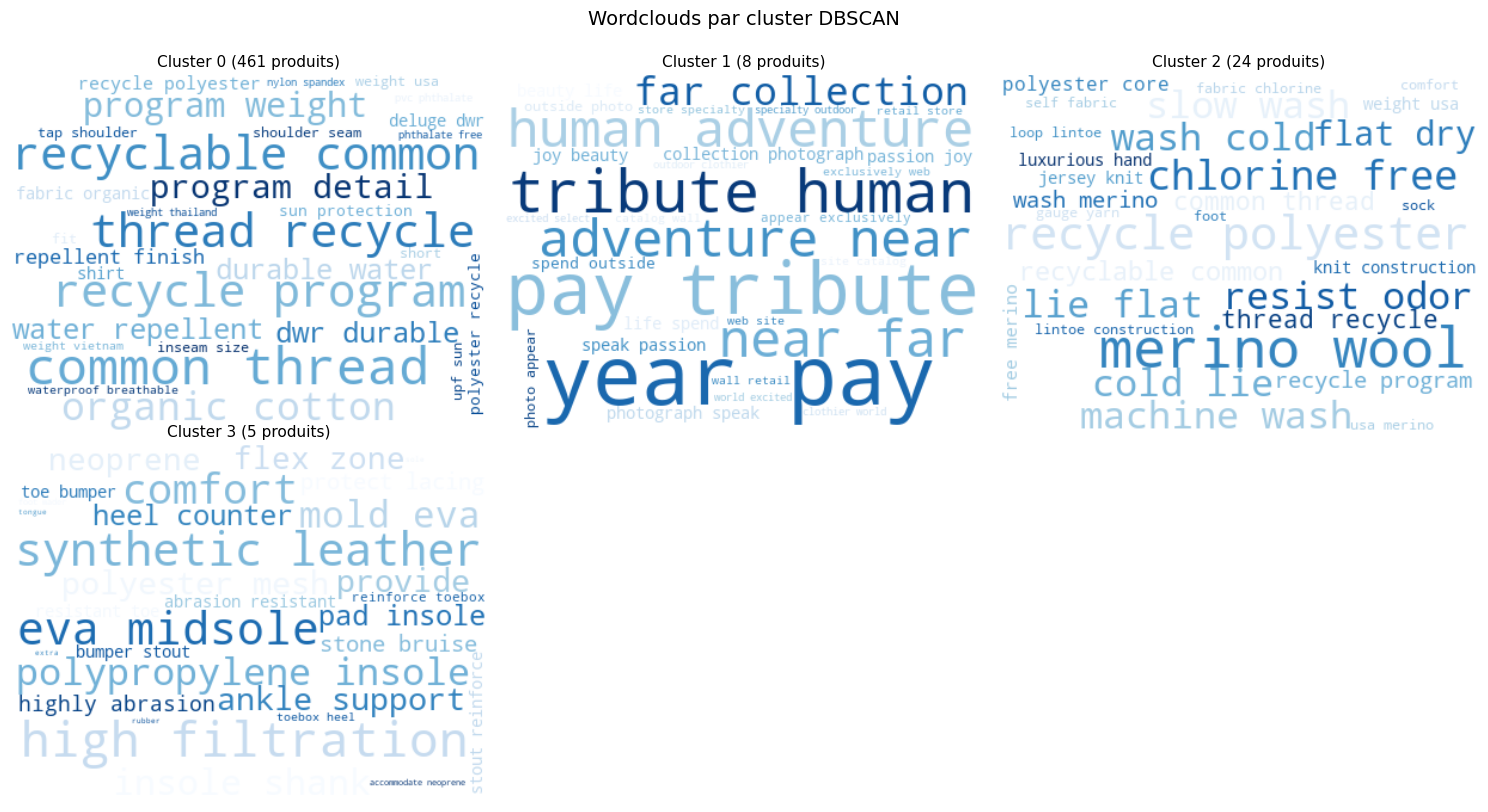

In [9]:
clusters_to_show = sorted([c for c in df['cluster'].unique() if c != -1])
n = len(clusters_to_show)
cols = 3
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
axes = axes.flatten()

for i, cluster_id in enumerate(clusters_to_show):
    texts = ' '.join(df[df['cluster'] == cluster_id]['description_processed'])
    wc = WordCloud(width=400, height=300, background_color='white',
                   max_words=30, colormap='Blues').generate(texts)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'Cluster {cluster_id} ({len(df[df["cluster"]==cluster_id])} produits)', fontsize=11)
    axes[i].axis('off')

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Wordclouds par cluster DBSCAN', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Partie 2 — Système de recommandation

L'idée est simple : deux produits dans le même cluster sont considérés comme similaires. La fonction `find_similar_items` prend un `item_id` et retourne 5 produits du même cluster.

Si le produit est un outlier (cluster -1), on utilise directement la similarité cosine pour trouver les plus proches.

In [10]:
def find_similar_items(item_id, n=5):
    """
    Retourne n produits similaires à item_id (même cluster).
    Si le produit est un outlier, on utilise la similarité cosine directement.
    """
    if item_id not in df['id'].values:
        return f"Produit {item_id} introuvable."

    row = df[df['id'] == item_id].iloc[0]
    cluster_id = row['cluster']

    if cluster_id == -1:
        idx = df[df['id'] == item_id].index[0]
        sims = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()
        sims[idx] = 0
        top_idx = sims.argsort()[-n:][::-1]
        return df.iloc[top_idx]['id'].tolist()

    cluster_items = df[(df['cluster'] == cluster_id) & (df['id'] != item_id)]['id'].tolist()
    return cluster_items[:n] if len(cluster_items) >= n else cluster_items


# Test sur quelques produits
for test_id in [1, 10, 50]:
    similar = find_similar_items(test_id)
    print(f"Produit {test_id} → similaires : {similar}")

Produit 1 → similaires : [2, 3, 4, 5, 6]
Produit 10 → similaires : [1, 2, 3, 4, 5]
Produit 50 → similaires : [1, 2, 3, 4, 5]


In [11]:
# Interface interactive — entrer un id produit pour obtenir des suggestions
try:
    user_input = input("Entrez l'id d'un produit (1-500) : ")
    item_id = int(user_input)
    results = find_similar_items(item_id)
    print(f"\nProduits similaires au produit {item_id} : {results}")
    print("\nDétail des suggestions :")
    for rid in results:
        desc = df[df['id'] == rid]['description_clean'].values[0]
        print(f"  [{rid}] {desc[:120]}...")
except Exception as e:
    print(f"Erreur : {e}")


Produits similaires au produit 1 : [2, 3, 4, 5, 6]

Détail des suggestions :
  [2] Active sport boxer briefs Skinning up Glory requires enough movement without your boxers deciding to poach their own rou...
  [3] Active sport briefs These superbreathable no fly briefs are the minimalist s choice for high octane endeavors Made from ...
  [4] Alpine guide pants Skin in climb ice switch to rock traverse a knife edge ridge and boogie back down these durable weath...
  [5] Alpine wind jkt On high ridges steep ice and anything alpine this jacket serves as a true best of all worlds staple It e...
  [6] Ascensionist jkt Our most technical soft shell for full on mountain pursuits strikes the alpinist s balance between prot...


## Partie 3 — Topic Modeling (LSA)

La **LSA (Latent Semantic Analysis)** utilise `TruncatedSVD` pour extraire des thèmes latents dans le corpus. Contrairement au clustering, chaque produit est associé à plusieurs topics simultanément — on extrait le topic dominant pour chaque produit.

La variance expliquée indique la part d'information capturée par les N topics.

In [12]:
N_TOPICS = 15

svd = TruncatedSVD(n_components=N_TOPICS, random_state=42)
topic_matrix = svd.fit_transform(tfidf_matrix)

topic_encoded_df = pd.DataFrame(
    topic_matrix,
    columns=[f'topic_{i}' for i in range(N_TOPICS)]
)
topic_encoded_df.index = df['id'].values

# Topic dominant pour chaque produit
df['main_topic'] = topic_matrix.argmax(axis=1)

print(f'Matrice topic : {topic_encoded_df.shape}')
print(f'Variance expliquée cumulée : {svd.explained_variance_ratio_.sum():.2%}')
print()
print(df['main_topic'].value_counts().sort_index())

Matrice topic : (500, 15)
Variance expliquée cumulée : 38.48%

main_topic
0     331
1      47
2       2
4      30
5      15
6      14
7      29
8       6
9      10
10     10
13      6
Name: count, dtype: int64


### Wordclouds par topic

Pour chaque topic, on représente les mots qui lui sont le plus associés (composantes SVD positives). Ça permet d'identifier des thèmes cohérents : vêtements imperméables, isolation thermique, équipement technique, etc.

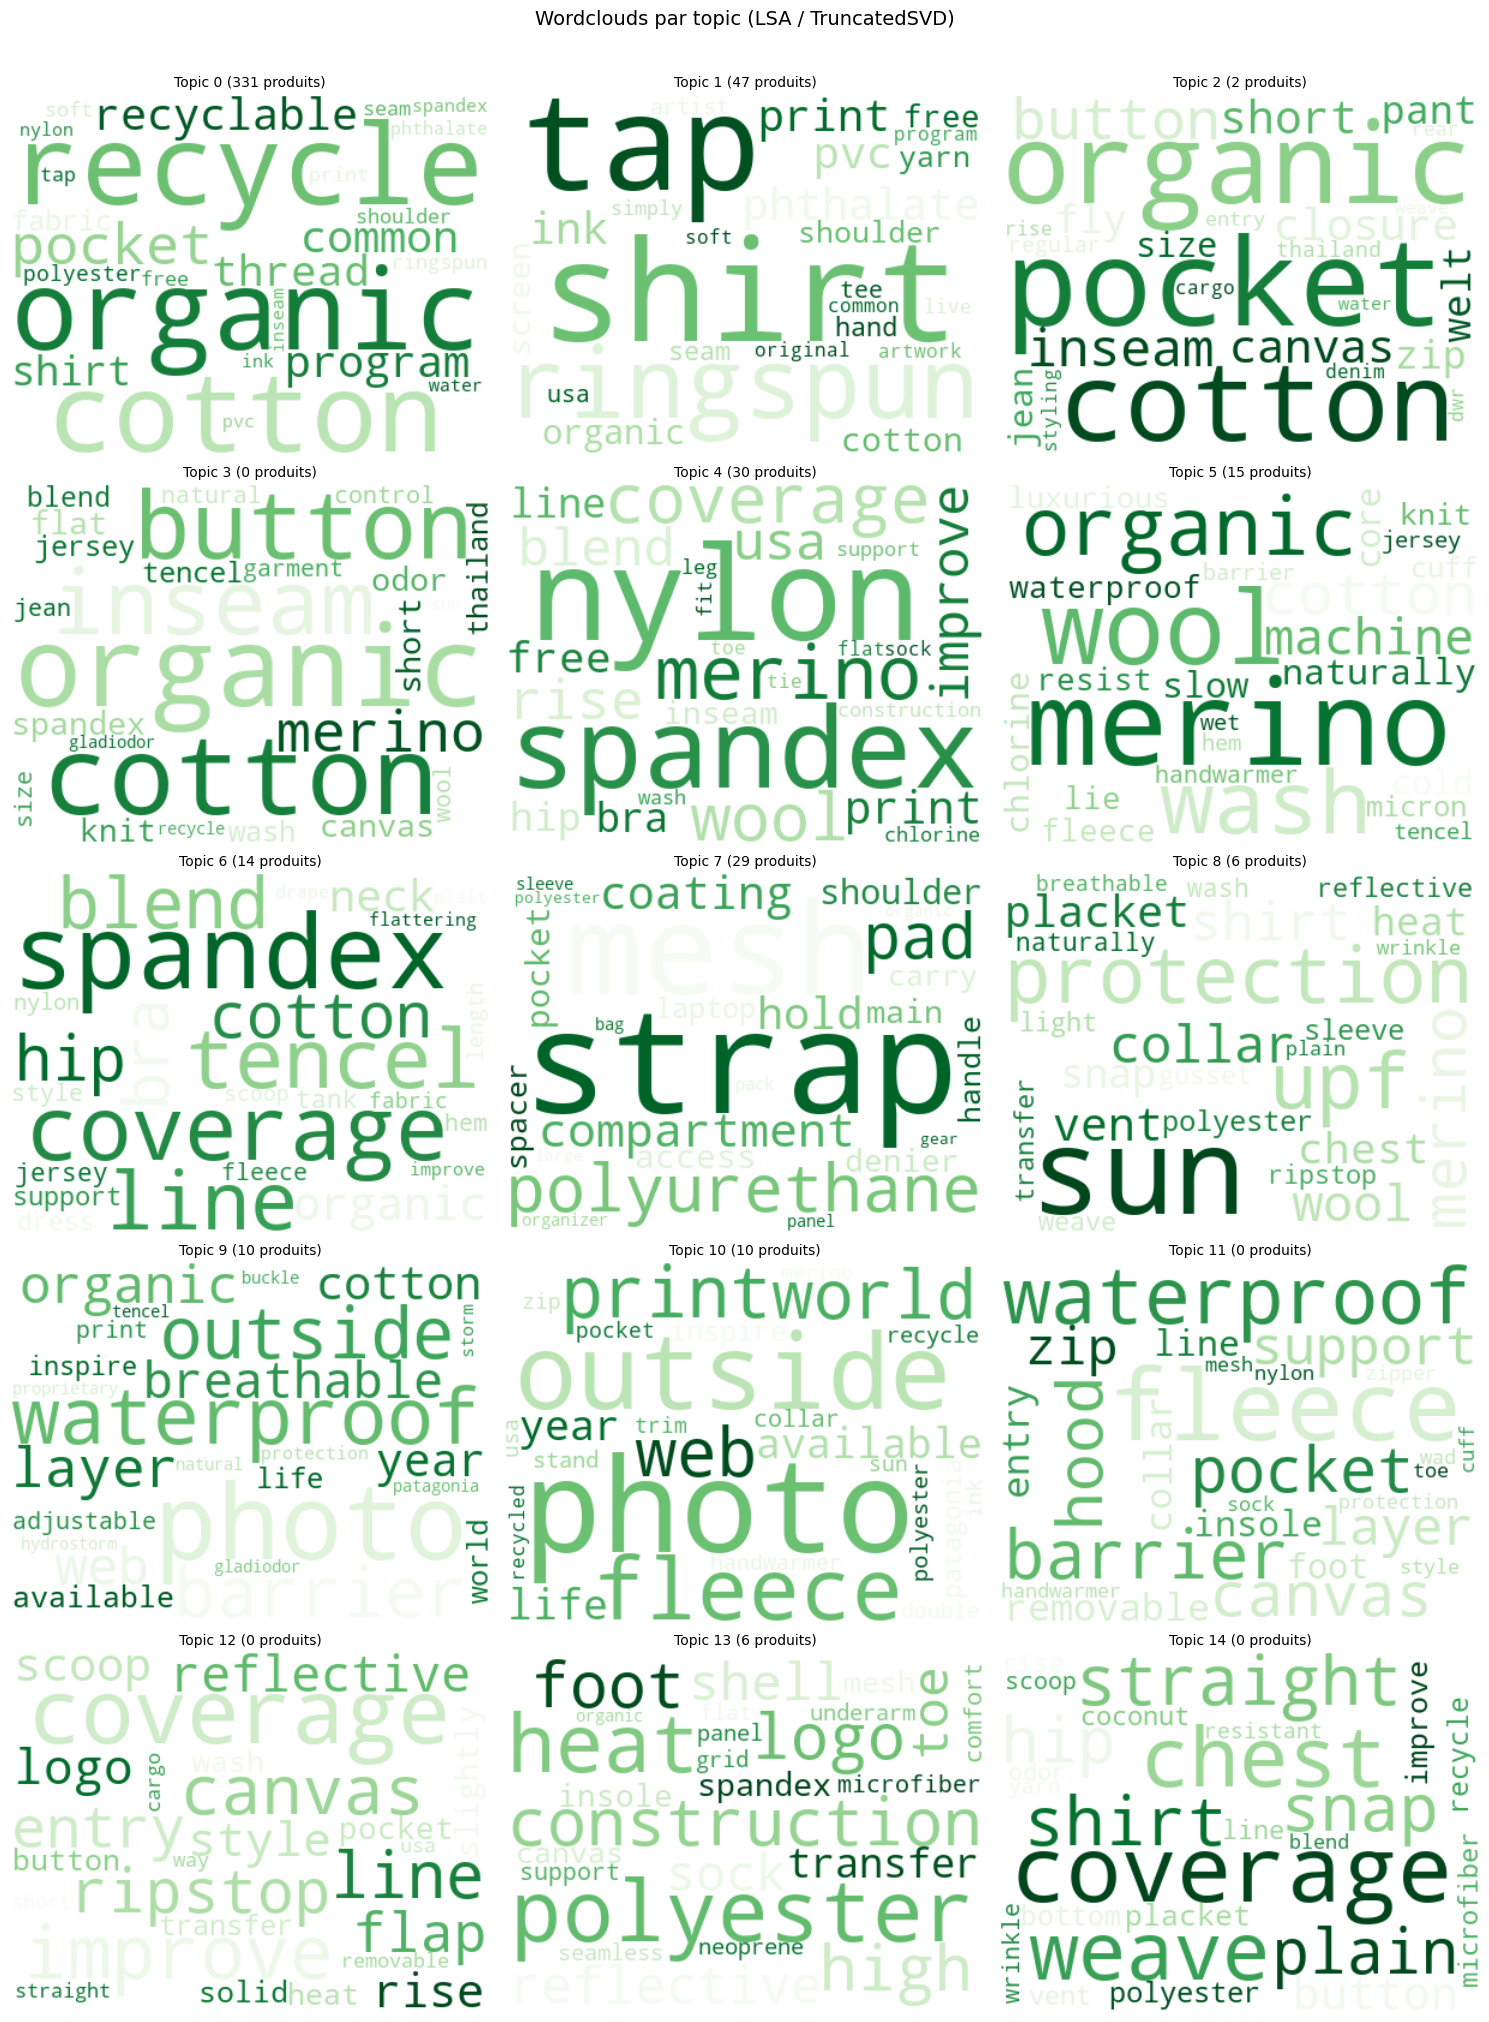

In [13]:
feature_names = vectorizer.get_feature_names_out()

cols = 3
rows = (N_TOPICS + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
axes = axes.flatten()

for i in range(N_TOPICS):
    components = svd.components_[i]
    word_weights = {feature_names[j]: max(components[j], 0) for j in range(len(feature_names))}
    word_weights = {k: v for k, v in word_weights.items() if v > 0}

    if word_weights:
        wc = WordCloud(width=400, height=300, background_color='white',
                       max_words=25, colormap='Greens').generate_from_frequencies(word_weights)
        axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'Topic {i} ({len(df[df["main_topic"]==i])} produits)', fontsize=10)
    axes[i].axis('off')

for j in range(N_TOPICS, len(axes)):
    axes[j].axis('off')

plt.suptitle('Wordclouds par topic (LSA / TruncatedSVD)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Conclusion

**Partie 1 — DBSCAN**
- L'algorithme regroupe les produits aux descriptions proches à l'aide de la similarité cosine sur la matrice TF-IDF
- Les wordclouds montrent des clusters cohérents : vêtements techniques, équipement outdoor, sous-vêtements, pantalons, etc.

**Partie 2 — Recommandation**
- La fonction `find_similar_items` retourne 5 produits du même cluster — simple et directement exploitable sur les pages produits du site
- Pour les outliers (produits très spécifiques), on bascule sur la similarité cosine brute

**Partie 3 — LSA**
- TruncatedSVD avec 15 composantes capture une bonne part de la variance du corpus
- Les topics font ressortir des thèmes cohérents : isolation thermique, protection pluie/vent, activités techniques (ski, escalade), matières (polyester recyclé, duvet...)
- La LSA complète bien le clustering : elle permet de nuancer l'appartenance d'un produit à plusieurs thèmes